### Cell 1 — Mount + imports + paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
OUT_DIR = BASE_DIR / "analysis" / "ct2dose_phase4_shoulder_aware_finetuning"

OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_MANIFEST = SPLIT_DIR / "train_pairs_3d_train_phase3_2000.json"
VAL_MANIFEST   = SPLIT_DIR / "train_pairs_3d_val_phase3_500.json"

BASE_CKPT = CKPT_DIR / "ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_best.pt"

print("TRAIN_MANIFEST exists:", TRAIN_MANIFEST.exists())
print("VAL_MANIFEST exists:", VAL_MANIFEST.exists())
print("BASE_CKPT exists:", BASE_CKPT.exists())

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

Mounted at /content/drive
TRAIN_MANIFEST exists: True
VAL_MANIFEST exists: True
BASE_CKPT exists: True
device: cuda


### Cell 2 — Title

In [2]:
from IPython.display import Markdown, display

display(Markdown(r"""
# CT-to-Dose Phase 4: Shoulder-Aware Fine-Tuning
## Starting point
- mixed T=0.15, alpha=0.30, max_weight=3.0

## Goal
- keep the current balanced mixed setup
- add a light shoulder-region refinement term
- fine-tune instead of retraining from scratch
"""))


# CT-to-Dose Phase 4: Shoulder-Aware Fine-Tuning
## Starting point
- mixed T=0.15, alpha=0.30, max_weight=3.0

## Goal
- keep the current balanced mixed setup
- add a light shoulder-region refinement term
- fine-tune instead of retraining from scratch


### Cell 3 — Dataset + model definitions

In [3]:
DOSE_SCALE = 1000.0
EPS = 1e-8

def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)
        x1 = torch.from_numpy(x1).unsqueeze(0)

        return x0, x1


class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])
        inp = torch.cat([xt, x0, t_map], dim=1)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b  = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)


@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z


def sample_t_like(x):
    return torch.rand((x.shape[0], 1, 1, 1, 1), device=x.device)

### Cell 4 — Config

In [4]:
RUN_NAME = "ct2dose_phase4_shoulder_aware_finetune_from_t015_lr1e4_ep12_b0p10"

LR = 1e-4
EPOCHS = 12
BATCH_SIZE = 2
BASE_CH = 24

THRESHOLD = 0.15
THRESHOLD_MODE = "absolute"

ALPHA = 0.30
BETA = 0.10
MAX_DOSE_WEIGHT = 3.0

SHOULDER_LOW = 0.30
SHOULDER_HIGH = 0.80

best_ckpt_path = CKPT_DIR / f"{RUN_NAME}_best.pt"
latest_ckpt_path = CKPT_DIR / f"{RUN_NAME}_latest.pt"
log_csv_path = OUT_DIR / f"{RUN_NAME}_training_log.csv"
summary_json_path = OUT_DIR / f"{RUN_NAME}_summary.json"

print("RUN_NAME:", RUN_NAME)
print("LR:", LR)
print("EPOCHS:", EPOCHS)
print("ALPHA:", ALPHA)
print("BETA:", BETA)
print("THRESHOLD:", THRESHOLD)
print("MAX_DOSE_WEIGHT:", MAX_DOSE_WEIGHT)
print("SHOULDER_LOW:", SHOULDER_LOW)
print("SHOULDER_HIGH:", SHOULDER_HIGH)

RUN_NAME: ct2dose_phase4_shoulder_aware_finetune_from_t015_lr1e4_ep12_b0p10
LR: 0.0001
EPOCHS: 12
ALPHA: 0.3
BETA: 0.1
THRESHOLD: 0.15
MAX_DOSE_WEIGHT: 3.0
SHOULDER_LOW: 0.3
SHOULDER_HIGH: 0.8


### Cell 5 — Weight and shoulder-mask helpers

In [5]:
def build_dose_weight_map_from_gt(gt_dose, threshold=0.15, mode="absolute", eps=1e-8):
    if mode == "absolute":
        T = torch.full_like(gt_dose, fill_value=threshold)
    elif mode == "relative_to_case_max":
        case_max = gt_dose.amax(dim=(1,2,3,4), keepdim=True)
        T = threshold * case_max.expand_as(gt_dose)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    T = torch.clamp(T, min=eps)
    weight = torch.maximum(T, gt_dose) / T
    return weight


def build_shoulder_mask_from_gt(gt_dose, low_ratio=0.30, high_ratio=0.80):
    """
    gt_dose: [B,1,D,H,W]
    shoulder region:
        low_ratio * case_max <= gt < high_ratio * case_max
    """
    case_max = gt_dose.amax(dim=(1,2,3,4), keepdim=True)
    low = low_ratio * case_max
    high = high_ratio * case_max

    mask = (gt_dose >= low) & (gt_dose < high)
    return mask.float()

### Cell 6 — Shoulder-aware fine-tuning loss

In [6]:
def compute_shoulder_aware_finetune_loss(
    model,
    x0,
    x1,
    threshold=0.15,
    mode="absolute",
    alpha=0.30,
    beta=0.10,
    max_dose_weight=3.0,
    shoulder_low=0.30,
    shoulder_high=0.80,
    eps=1e-8
):
    """
    base_loss:
        mean squared flow-matching error

    weighted_loss:
        high-dose weighted version, same as current mixed baseline

    shoulder_loss:
        mean squared error only over the shoulder region
        (0.3*max <= gt < 0.8*max)

    final:
        (1 - alpha - beta)*base + alpha*weighted + beta*shoulder
    """
    assert alpha + beta < 1.0, "Need alpha + beta < 1"

    t = sample_t_like(x0)
    z_t = (1.0 - t) * x0 + t * x1

    v_target = x1 - x0
    v_pred = model(z_t, x0, t)

    sq_err = (v_pred - v_target) ** 2
    base_loss = sq_err.mean()

    dose_weight = build_dose_weight_map_from_gt(
        x1, threshold=threshold, mode=mode, eps=eps
    )
    if max_dose_weight is not None:
        dose_weight = torch.clamp(dose_weight, max=max_dose_weight)

    weighted_loss = (dose_weight * sq_err).sum() / (dose_weight.sum() + eps)

    shoulder_mask = build_shoulder_mask_from_gt(
        x1,
        low_ratio=shoulder_low,
        high_ratio=shoulder_high
    )

    shoulder_voxels = shoulder_mask.sum()
    if shoulder_voxels.item() > 0:
        shoulder_loss = (shoulder_mask * sq_err).sum() / (shoulder_voxels + eps)
    else:
        shoulder_loss = torch.zeros_like(base_loss)

    final_loss = (
        (1.0 - alpha - beta) * base_loss
        + alpha * weighted_loss
        + beta * shoulder_loss
    )

    aux = {
        "base_loss": float(base_loss.item()),
        "weighted_loss": float(weighted_loss.item()),
        "shoulder_loss": float(shoulder_loss.item()),
        "final_loss": float(final_loss.item()),
        "dose_weight_mean": float(dose_weight.mean().item()),
        "dose_weight_max": float(dose_weight.max().item()),
        "shoulder_fraction": float(shoulder_mask.mean().item()),
    }
    return final_loss, aux

### Cell 7 — Datasets and loaders

In [7]:
train_dataset_3d = CubePair3DDataset(TRAIN_MANIFEST, dose_scale=DOSE_SCALE)
val_dataset_3d   = CubePair3DDataset(VAL_MANIFEST, dose_scale=DOSE_SCALE)

train_loader_3d = DataLoader(
    train_dataset_3d,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader_3d = DataLoader(
    val_dataset_3d,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train samples:", len(train_dataset_3d))
print("Val samples:", len(val_dataset_3d))

Train samples: 2000
Val samples: 500


### Cell 8 — Train/validation loops

In [8]:
def train_one_epoch_shoulder_aware(model, loader, optimizer, device):
    model.train()

    total_final = 0.0
    total_base = 0.0
    total_weighted = 0.0
    total_shoulder = 0.0
    total_dose_w_mean = 0.0
    total_dose_w_max = 0.0
    total_shoulder_frac = 0.0
    total_count = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        loss, aux = compute_shoulder_aware_finetune_loss(
            model,
            x0, x1,
            threshold=THRESHOLD,
            mode=THRESHOLD_MODE,
            alpha=ALPHA,
            beta=BETA,
            max_dose_weight=MAX_DOSE_WEIGHT,
            shoulder_low=SHOULDER_LOW,
            shoulder_high=SHOULDER_HIGH,
            eps=EPS
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = x0.shape[0]
        total_final += aux["final_loss"] * bs
        total_base += aux["base_loss"] * bs
        total_weighted += aux["weighted_loss"] * bs
        total_shoulder += aux["shoulder_loss"] * bs
        total_dose_w_mean += aux["dose_weight_mean"] * bs
        total_dose_w_max += aux["dose_weight_max"] * bs
        total_shoulder_frac += aux["shoulder_fraction"] * bs
        total_count += bs

    return {
        "train_final_loss": total_final / total_count,
        "train_base_loss": total_base / total_count,
        "train_weighted_loss": total_weighted / total_count,
        "train_shoulder_loss": total_shoulder / total_count,
        "train_dose_weight_mean": total_dose_w_mean / total_count,
        "train_dose_weight_max": total_dose_w_max / total_count,
        "train_shoulder_fraction": total_shoulder_frac / total_count,
    }


@torch.no_grad()
def validate_one_epoch_shoulder_aware(model, loader, device):
    model.eval()

    total_final = 0.0
    total_base = 0.0
    total_weighted = 0.0
    total_shoulder = 0.0
    total_dose_w_mean = 0.0
    total_dose_w_max = 0.0
    total_shoulder_frac = 0.0
    total_count = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        loss, aux = compute_shoulder_aware_finetune_loss(
            model,
            x0, x1,
            threshold=THRESHOLD,
            mode=THRESHOLD_MODE,
            alpha=ALPHA,
            beta=BETA,
            max_dose_weight=MAX_DOSE_WEIGHT,
            shoulder_low=SHOULDER_LOW,
            shoulder_high=SHOULDER_HIGH,
            eps=EPS
        )

        bs = x0.shape[0]
        total_final += aux["final_loss"] * bs
        total_base += aux["base_loss"] * bs
        total_weighted += aux["weighted_loss"] * bs
        total_shoulder += aux["shoulder_loss"] * bs
        total_dose_w_mean += aux["dose_weight_mean"] * bs
        total_dose_w_max += aux["dose_weight_max"] * bs
        total_shoulder_frac += aux["shoulder_fraction"] * bs
        total_count += bs

    return {
        "val_final_loss": total_final / total_count,
        "val_base_loss": total_base / total_count,
        "val_weighted_loss": total_weighted / total_count,
        "val_shoulder_loss": total_shoulder / total_count,
        "val_dose_weight_mean": total_dose_w_mean / total_count,
        "val_dose_weight_max": total_dose_w_max / total_count,
        "val_shoulder_fraction": total_shoulder_frac / total_count,
    }

### Cell 9 — Build model and load base checkpoint

In [9]:
base_ckpt = torch.load(BASE_CKPT, map_location="cpu")

model = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=BASE_CH).to(device)
model.load_state_dict(base_ckpt["model_state_dict"])

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = []
best_val_loss = float("inf")
best_epoch = -1
start_time = time.time()

print("Loaded base checkpoint:", BASE_CKPT)
print("Base run name:", base_ckpt.get("run_name", "N/A"))

Loaded base checkpoint: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_best.pt
Base run name: ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3


### Cell 10 — Main fine-tuning loop

In [10]:
for epoch in range(1, EPOCHS + 1):
    train_stats = train_one_epoch_shoulder_aware(model, train_loader_3d, optimizer, device)
    val_stats = validate_one_epoch_shoulder_aware(model, val_loader_3d, device)

    row = {"epoch": epoch, **train_stats, **val_stats}
    history.append(row)

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "run_name": RUN_NAME,
        "base_checkpoint": str(BASE_CKPT),
        "threshold": THRESHOLD,
        "threshold_mode": THRESHOLD_MODE,
        "alpha": ALPHA,
        "beta": BETA,
        "max_dose_weight": MAX_DOSE_WEIGHT,
        "shoulder_low": SHOULDER_LOW,
        "shoulder_high": SHOULDER_HIGH,
        "lr": LR,
        "base_ch": BASE_CH,
    }, latest_ckpt_path)

    if val_stats["val_final_loss"] < best_val_loss:
        best_val_loss = val_stats["val_final_loss"]
        best_epoch = epoch
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "run_name": RUN_NAME,
            "base_checkpoint": str(BASE_CKPT),
            "threshold": THRESHOLD,
            "threshold_mode": THRESHOLD_MODE,
            "alpha": ALPHA,
            "beta": BETA,
            "max_dose_weight": MAX_DOSE_WEIGHT,
            "shoulder_low": SHOULDER_LOW,
            "shoulder_high": SHOULDER_HIGH,
            "lr": LR,
            "base_ch": BASE_CH,
            "best_val_loss": best_val_loss,
        }, best_ckpt_path)

    print(
        f"Epoch {epoch:03d} | "
        f"train_final={train_stats['train_final_loss']:.6e} | "
        f"val_final={val_stats['val_final_loss']:.6e} | "
        f"train_base={train_stats['train_base_loss']:.6e} | "
        f"val_base={val_stats['val_base_loss']:.6e} | "
        f"train_w={train_stats['train_weighted_loss']:.6e} | "
        f"val_w={val_stats['val_weighted_loss']:.6e} | "
        f"train_sh={train_stats['train_shoulder_loss']:.6e} | "
        f"val_sh={val_stats['val_shoulder_loss']:.6e} | "
        f"shoulder_frac={train_stats['train_shoulder_fraction']:.3f}"
    )

elapsed_min = (time.time() - start_time) / 60.0
print("Fine-tuning finished. elapsed_min =", elapsed_min)

Epoch 001 | train_final=7.075426e-05 | val_final=1.743809e-04 | train_base=1.531161e-05 | val_base=2.010254e-05 | train_w=1.808027e-05 | val_w=2.664783e-05 | train_sh=5.614321e-04 | val_sh=1.543250e-03 | shoulder_frac=0.001
Epoch 002 | train_final=5.825587e-05 | val_final=8.352598e-05 | train_base=1.430331e-05 | val_base=1.581718e-05 | train_w=1.667254e-05 | val_w=1.917919e-05 | train_sh=4.467212e-04 | val_sh=6.828191e-04 | shoulder_frac=0.001
Epoch 003 | train_final=5.624036e-05 | val_final=5.550349e-05 | train_base=1.476957e-05 | val_base=1.519943e-05 | train_w=1.705201e-05 | val_w=1.767600e-05 | train_sh=4.226301e-04 | val_sh=4.108103e-04 | shoulder_frac=0.001
Epoch 004 | train_final=5.363015e-05 | val_final=4.667658e-05 | train_base=1.412977e-05 | val_base=1.468199e-05 | train_w=1.633997e-05 | val_w=1.680733e-05 | train_sh=4.025029e-04 | val_sh=3.282518e-04 | shoulder_frac=0.001
Epoch 005 | train_final=5.294474e-05 | val_final=4.570471e-05 | train_base=1.416884e-05 | val_base=1.305

### Cell 11 — Save logs and summary

In [11]:
history_df = pd.DataFrame(history)
history_df.to_csv(log_csv_path, index=False)

summary = {
    "run_name": RUN_NAME,
    "base_checkpoint": str(BASE_CKPT),
    "epochs": EPOCHS,
    "lr": LR,
    "base_ch": BASE_CH,
    "batch_size": BATCH_SIZE,
    "threshold": THRESHOLD,
    "threshold_mode": THRESHOLD_MODE,
    "alpha": ALPHA,
    "beta": BETA,
    "max_dose_weight": MAX_DOSE_WEIGHT,
    "shoulder_low": SHOULDER_LOW,
    "shoulder_high": SHOULDER_HIGH,
    "best_epoch": best_epoch,
    "best_val_loss": float(best_val_loss),
    "elapsed_min": float(elapsed_min),
    "best_ckpt_path": str(best_ckpt_path),
    "latest_ckpt_path": str(latest_ckpt_path),
}

with open(summary_json_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:", log_csv_path)
print("Saved:", summary_json_path)
print(json.dumps(summary, indent=2))

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_finetuning/ct2dose_phase4_shoulder_aware_finetune_from_t015_lr1e4_ep12_b0p10_training_log.csv
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_finetuning/ct2dose_phase4_shoulder_aware_finetune_from_t015_lr1e4_ep12_b0p10_summary.json
{
  "run_name": "ct2dose_phase4_shoulder_aware_finetune_from_t015_lr1e4_ep12_b0p10",
  "base_checkpoint": "/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_best.pt",
  "epochs": 12,
  "lr": 0.0001,
  "base_ch": 24,
  "batch_size": 2,
  "threshold": 0.15,
  "threshold_mode": "absolute",
  "alpha": 0.3,
  "beta": 0.1,
  "max_dose_weight": 3.0,
  "shoulder_low": 0.3,
  "shoulder_high": 0.8,
  "best_epoch": 11,
  "best_val_loss": 4.451776524001616e-05,
  "elapsed_min": 39.75323759317398,
  "best_ckpt_path": "/content/drive/MyDrive/rectified_flow

### Cell 12 — Final loss curve

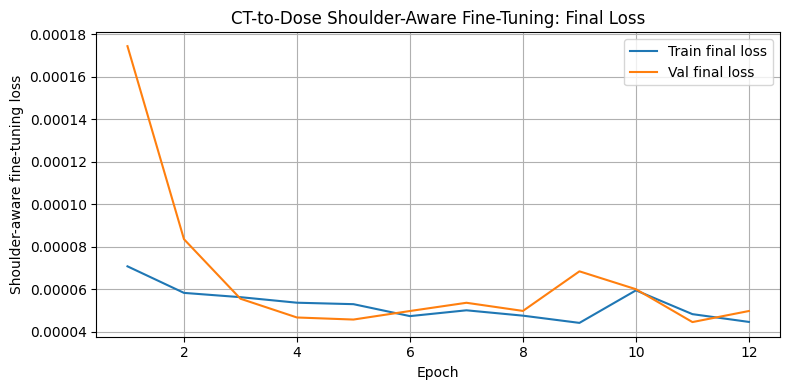

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_finetuning/ct2dose_phase4_shoulder_aware_finetune_from_t015_lr1e4_ep12_b0p10_final_loss_curve.png


In [12]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_final_loss"], label="Train final loss")
plt.plot(history_df["epoch"], history_df["val_final_loss"], label="Val final loss")
plt.xlabel("Epoch")
plt.ylabel("Shoulder-aware fine-tuning loss")
plt.title("CT-to-Dose Shoulder-Aware Fine-Tuning: Final Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()

final_loss_curve_path = OUT_DIR / f"{RUN_NAME}_final_loss_curve.png"
plt.savefig(final_loss_curve_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", final_loss_curve_path)

### Cell 13 — Base / weighted / shoulder components

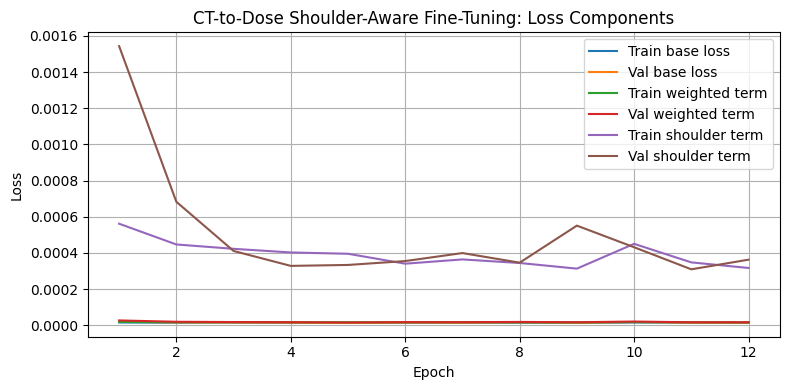

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_finetuning/ct2dose_phase4_shoulder_aware_finetune_from_t015_lr1e4_ep12_b0p10_loss_components.png


In [13]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_base_loss"], label="Train base loss")
plt.plot(history_df["epoch"], history_df["val_base_loss"], label="Val base loss")
plt.plot(history_df["epoch"], history_df["train_weighted_loss"], label="Train weighted term")
plt.plot(history_df["epoch"], history_df["val_weighted_loss"], label="Val weighted term")
plt.plot(history_df["epoch"], history_df["train_shoulder_loss"], label="Train shoulder term")
plt.plot(history_df["epoch"], history_df["val_shoulder_loss"], label="Val shoulder term")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CT-to-Dose Shoulder-Aware Fine-Tuning: Loss Components")
plt.grid(True)
plt.legend()
plt.tight_layout()

component_curve_path = OUT_DIR / f"{RUN_NAME}_loss_components.png"
plt.savefig(component_curve_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", component_curve_path)

### Cell 14 — Visualize shoulder mask on one val sample

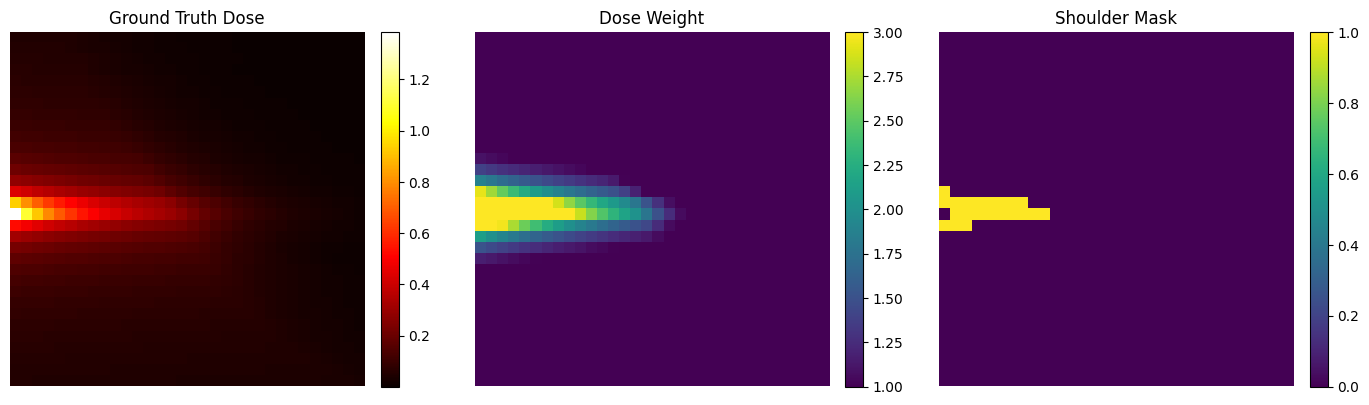

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_finetuning/ct2dose_phase4_shoulder_aware_finetune_from_t015_lr1e4_ep12_b0p10_shoulder_mask_example.png


In [14]:
sample_idx = len(val_dataset_3d) // 2
x0, x1 = val_dataset_3d[sample_idx]

gt = x1.unsqueeze(0).to(device)

dose_weight = build_dose_weight_map_from_gt(
    gt, threshold=THRESHOLD, mode=THRESHOLD_MODE, eps=EPS
)
dose_weight = torch.clamp(dose_weight, max=MAX_DOSE_WEIGHT)

shoulder_mask = build_shoulder_mask_from_gt(
    gt,
    low_ratio=SHOULDER_LOW,
    high_ratio=SHOULDER_HIGH
)

gt_np = gt.cpu().squeeze().numpy()
dose_weight_np = dose_weight.cpu().squeeze().numpy()
shoulder_mask_np = shoulder_mask.cpu().squeeze().numpy()

slice_idx = np.argmax(gt_np.reshape(gt_np.shape[0], -1).sum(axis=1))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(gt_np[slice_idx], cmap="hot")
axes[0].set_title("Ground Truth Dose")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(dose_weight_np[slice_idx], cmap="viridis")
axes[1].set_title("Dose Weight")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(shoulder_mask_np[slice_idx], cmap="viridis")
axes[2].set_title("Shoulder Mask")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()

mask_vis_path = OUT_DIR / f"{RUN_NAME}_shoulder_mask_example.png"
plt.savefig(mask_vis_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", mask_vis_path)